In [1]:
import torch
import torch.nn as nn
import sklearn
import numpy as np

## Данные: Iris

sklearn-датасет: X — 4 признака (длины/ширины чашелистиков и лепестков), y — 3 класса. Разбиваем 80/20 (test_size=0.2, random_state=42) для контроля переобучения.

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris['data']
y = iris['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Подготовка данных

- Z-нормализация признаков (X − mean) / std — ускоряет сходимость градиентного спуска.
- `TensorDataset` связывает признаки и метки; `DataLoader` выдаёт батчи по 2 с перемешиванием (shuffle=True).

In [3]:
from torch.utils.data import TensorDataset, DataLoader

X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm).float() 
y_train = torch.from_numpy(y_train)
train_ds = TensorDataset(X_train_norm, y_train)
torch.manual_seed(1)
batch_size = 2
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [4]:
class Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = nn.Sigmoid()(x)
        x = self.layer2(x)
        return x

input_size = X_train_norm.shape[1]
hidden_size = 16
output_size = 3
model = Model(input_size, hidden_size, output_size)

## Архитектура

MLP: `Linear(4 → 16)` → Sigmoid → `Linear(16 → 3)`. Выходной слой без активации — это logits, которые далее идут в loss.

In [8]:
lr = 0.001
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

## Loss и оптимизатор

`CrossEntropyLoss` сам применяет softmax к logits и считает cross-entropy. Adam (lr=0.001) — адаптивный оптимизатор, стандарт для такого рода задач.

In [10]:
num_epochs = 100
loss_history = [0] * num_epochs
accuracy_history = [0] * num_epochs  

for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_history[epoch] += loss.item()*y_batch.size(0)
        is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
        accuracy_history[epoch] += is_correct.sum() 
    loss_history[epoch] /= len(train_dl.dataset)
    accuracy_history[epoch] /= len(train_dl.dataset)          
        

## Цикл обучения

На каждый батч: forward → loss → `backward()` → `optimizer.step()` → `zero_grad()`. По эпохе усредняем loss и считаем accuracy.

## Результаты

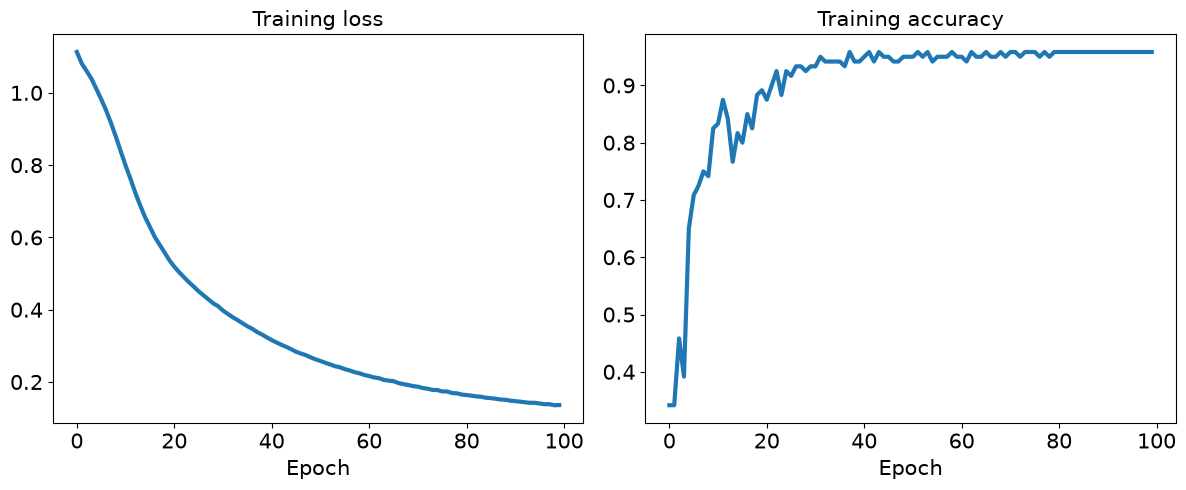

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(1, 2, 1)
ax.plot(loss_history, lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_history, lw=3)
ax.set_title('Training accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()